In [1]:
import os
import sys

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

from pyspark.ml.feature import VectorAssembler
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

import matplotlib.pyplot as plt

In [2]:
python_path = sys.executable

os.environ["PYSPARK_PYTHON"] = python_path
os.environ["PYSPARK_DRIVER_PYTHON"] = python_path

In [3]:
spark = (
    SparkSession.builder
    .appName("ChicagoCrime_Clustering")
    .master("local[*]")
    .config("spark.sql.shuffle.partitions", "8")
    .getOrCreate()
)

spark.sparkContext.setLogLevel("WARN")

print("Spark version:", spark.version)

Spark version: 4.2.0


In [4]:
BASE_PATH = r"C:\Users\HP\Documents\Big Data Technology"

PROCESSED_PATH = os.path.join(
    BASE_PATH,
    "data",
    "processed"
)

CRIME_PARQUET_PATH = os.path.join(
    PROCESSED_PATH,
    "integrated_crime_parquet"
)

print("Parquet path:", CRIME_PARQUET_PATH)

Parquet path: C:\Users\HP\Documents\Big Data Technology\data\processed\integrated_crime_parquet


In [5]:
integrated_crime = spark.read.parquet(CRIME_PARQUET_PATH)

print("Rows:", integrated_crime.count())
integrated_crime.printSchema()

Rows: 7784664
root
 |-- ID: integer (nullable = true)
 |-- Case Number: string (nullable = true)
 |-- Date: string (nullable = true)
 |-- Block: string (nullable = true)
 |-- IUCR: string (nullable = true)
 |-- Primary Type: string (nullable = true)
 |-- Description: string (nullable = true)
 |-- Location Description: string (nullable = true)
 |-- Arrest: boolean (nullable = true)
 |-- Domestic: boolean (nullable = true)
 |-- Beat: integer (nullable = true)
 |-- District: integer (nullable = true)
 |-- Ward: integer (nullable = true)
 |-- Community Area: integer (nullable = true)
 |-- FBI Code: string (nullable = true)
 |-- X Coordinate: double (nullable = true)
 |-- Y Coordinate: double (nullable = true)
 |-- Year: integer (nullable = true)
 |-- Updated On: string (nullable = true)
 |-- Latitude: double (nullable = true)
 |-- Longitude: double (nullable = true)
 |-- Location: string (nullable = true)
 |-- crime_timestamp: timestamp (nullable = true)
 |-- crime_date: date (nullable = t

In [6]:
#Check clustering variables
integrated_crime.select(
    "latitude_clean",
    "longitude_clean",
    "crime_hour",
    "district_clean"
).show(10, truncate=False)

+--------------+---------------+----------+--------------+
|latitude_clean|longitude_clean|crime_hour|district_clean|
+--------------+---------------+----------+--------------+
|41.801875741  |-87.723408371  |8         |8             |
|41.771259454  |-87.687091027  |17        |8             |
|41.797419318  |-87.762445797  |2         |8             |
|41.748201953  |-87.688091884  |11        |8             |
|41.779160614  |-87.722773075  |9         |8             |
|41.764201367  |-87.685673675  |10        |8             |
|41.764450345  |-87.698320777  |17        |8             |
|41.780714508  |-87.767935966  |20        |8             |
|41.798137854  |-87.734328695  |18        |8             |
|41.744654208  |-87.710084277  |19        |8             |
+--------------+---------------+----------+--------------+
only showing top 10 rows


In [7]:
integrated_crime.select(
    F.sum(F.col("latitude_clean").isNull().cast("int")).alias("missing_latitude"),
    F.sum(F.col("longitude_clean").isNull().cast("int")).alias("missing_longitude"),
    F.sum(F.col("crime_hour").isNull().cast("int")).alias("missing_hour"),
    F.sum(F.col("district_clean").isNull().cast("int")).alias("missing_district")
).show()

+----------------+-----------------+------------+----------------+
|missing_latitude|missing_longitude|missing_hour|missing_district|
+----------------+-----------------+------------+----------------+
|           86966|            86966|           0|              47|
+----------------+-----------------+------------+----------------+



In [8]:
#Prepare the clustering dataset
clustering_data = (
    integrated_crime
    .select(
        "latitude_clean",
        "longitude_clean",
        "crime_hour",
        "district_clean",
        "community_area_clean",
        "Primary Type"
    )
    .where(
        F.col("latitude_clean").isNotNull()
        & F.col("longitude_clean").isNotNull()
        & F.col("crime_hour").isNotNull()
    )
)

print("Clustering rows:", clustering_data.count())

clustering_data.show(10, truncate=False)

Clustering rows: 7697698
+--------------+---------------+----------+--------------+--------------------+-------------------+
|latitude_clean|longitude_clean|crime_hour|district_clean|community_area_clean|Primary Type       |
+--------------+---------------+----------+--------------+--------------------+-------------------+
|41.801875741  |-87.723408371  |8         |8             |57                  |THEFT              |
|41.771259454  |-87.687091027  |17        |8             |66                  |BATTERY            |
|41.797419318  |-87.762445797  |2         |8             |56                  |OTHER OFFENSE      |
|41.748201953  |-87.688091884  |11        |8             |70                  |BATTERY            |
|41.779160614  |-87.722773075  |9         |8             |65                  |THEFT              |
|41.764201367  |-87.685673675  |10        |8             |66                  |ROBBERY            |
|41.764450345  |-87.698320777  |17        |8             |66               

In [9]:
#Create the feature vector
from pyspark.ml.feature import VectorAssembler

assembler = VectorAssembler(
    inputCols=[
        "latitude_clean",
        "longitude_clean",
        "crime_hour"
    ],
    outputCol="features"
)

cluster_features = assembler.transform(clustering_data)

cluster_features.select(
    "latitude_clean",
    "longitude_clean",
    "crime_hour",
    "features"
).show(10, truncate=False)

+--------------+---------------+----------+---------------------------------+
|latitude_clean|longitude_clean|crime_hour|features                         |
+--------------+---------------+----------+---------------------------------+
|41.801875741  |-87.723408371  |8         |[41.801875741,-87.723408371,8.0] |
|41.771259454  |-87.687091027  |17        |[41.771259454,-87.687091027,17.0]|
|41.797419318  |-87.762445797  |2         |[41.797419318,-87.762445797,2.0] |
|41.748201953  |-87.688091884  |11        |[41.748201953,-87.688091884,11.0]|
|41.779160614  |-87.722773075  |9         |[41.779160614,-87.722773075,9.0] |
|41.764201367  |-87.685673675  |10        |[41.764201367,-87.685673675,10.0]|
|41.764450345  |-87.698320777  |17        |[41.764450345,-87.698320777,17.0]|
|41.780714508  |-87.767935966  |20        |[41.780714508,-87.767935966,20.0]|
|41.798137854  |-87.734328695  |18        |[41.798137854,-87.734328695,18.0]|
|41.744654208  |-87.710084277  |19        |[41.744654208,-87.710

In [10]:
#Create a modelling sample
cluster_sample = (
    cluster_features
    .select("features")
    .sample(
        withReplacement=False,
        fraction=0.10,
        seed=42
    )
    .cache()
)

print("Sample rows:", cluster_sample.count())

Sample rows: 770201


In [11]:
#Check the sample
cluster_sample.show(10, truncate=False)
print("Sample rows:", cluster_sample.count())

+---------------------------------+
|features                         |
+---------------------------------+
|[41.780714508,-87.767935966,20.0]|
|[41.754592961,-87.741528537,19.0]|
|[41.745685472,-87.692514388,21.0]|
|[41.78261849,-87.702468048,14.0] |
|[41.779076327,-87.696134362,18.0]|
|[41.812687132,-87.744768701,13.0]|
|[41.764646721,-87.722390196,7.0] |
|[41.788961533,-87.704649996,23.0]|
|[41.787873172,-87.68753656,14.0] |
|[41.769364272,-87.688268431,5.0] |
+---------------------------------+
only showing top 10 rows
Sample rows: 770201


In [12]:
from pyspark.ml.clustering import KMeans
from pyspark.ml.evaluation import ClusteringEvaluator

k_values = [2, 3, 4, 5, 6, 7, 8]

silhouette_scores = []

evaluator = ClusteringEvaluator(
    featuresCol="features",
    predictionCol="prediction",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

for k in k_values:
    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol="features",
        predictionCol="prediction"
    )

    model = kmeans.fit(cluster_sample)

    predictions = model.transform(cluster_sample)

    score = evaluator.evaluate(predictions)

    silhouette_scores.append(score)

    print(f"K = {k}, Silhouette = {score:.4f}")

K = 2, Silhouette = 0.7673
K = 3, Silhouette = 0.7639
K = 4, Silhouette = 0.7482
K = 5, Silhouette = 0.7277
K = 6, Silhouette = 0.7234
K = 7, Silhouette = 0.6799
K = 8, Silhouette = 0.6486


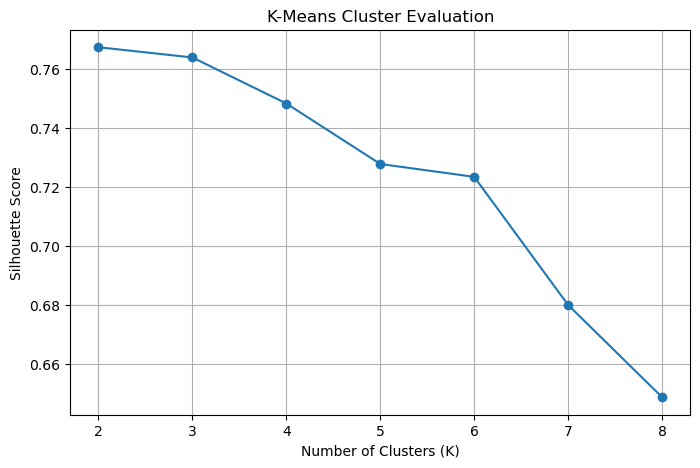

In [13]:
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("K-Means Cluster Evaluation")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [14]:
#alculate WSSSE / Within-Cluster Cost
wssse_scores = []

for k in k_values:
    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol="features",
        predictionCol="prediction"
    )

    model = kmeans.fit(cluster_sample)

    wssse = model.summary.trainingCost

    wssse_scores.append(wssse)

    print(f"K = {k}, WSSSE = {wssse:.2f}")

K = 2, WSSSE = 10153366.01
K = 3, WSSSE = 4128517.41
K = 4, WSSSE = 2109079.04
K = 5, WSSSE = 1639539.43
K = 6, WSSSE = 1123198.20
K = 7, WSSSE = 783570.25
K = 8, WSSSE = 661812.34


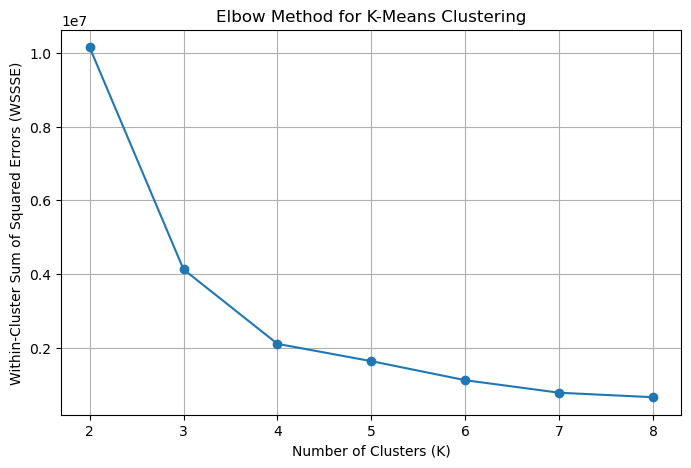

In [15]:
#Plot the Elbow Curve
plt.figure(figsize=(8, 5))

plt.plot(
    k_values,
    wssse_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Within-Cluster Sum of Squared Errors (WSSSE)")
plt.title("Elbow Method for K-Means Clustering")

plt.xticks(k_values)
plt.grid(True)

plt.show()

In [16]:
#Create a results table
cluster_evaluation = list(
    zip(
        k_values,
        silhouette_scores,
        wssse_scores
    )
)

for k, silhouette, wssse in cluster_evaluation:
    print(
        f"K = {k} | "
        f"Silhouette = {silhouette:.4f} | "
        f"WSSSE = {wssse:.2f}"
    )

K = 2 | Silhouette = 0.7673 | WSSSE = 10153366.01
K = 3 | Silhouette = 0.7639 | WSSSE = 4128517.41
K = 4 | Silhouette = 0.7482 | WSSSE = 2109079.04
K = 5 | Silhouette = 0.7277 | WSSSE = 1639539.43
K = 6 | Silhouette = 0.7234 | WSSSE = 1123198.20
K = 7 | Silhouette = 0.6799 | WSSSE = 783570.25
K = 8 | Silhouette = 0.6486 | WSSSE = 661812.34


In [17]:
best_result = max(
    cluster_evaluation,
    key=lambda x: x[1]
)

best_k = best_result[0]

print("Selected K:", best_k)
print("Silhouette score:", round(best_result[1], 4))
print("WSSSE:", round(best_result[2], 2))

Selected K: 2
Silhouette score: 0.7673
WSSSE: 10153366.01


In [18]:
#train K-means model
final_kmeans = KMeans(
    k=best_k,
    seed=42,
    featuresCol="features",
    predictionCol="prediction"
)

final_model = final_kmeans.fit(cluster_sample)

print("Final K-Means model trained successfully.")

Final K-Means model trained successfully.


In [19]:
#Get the cluster centers
cluster_centers = final_model.clusterCenters()

for i, center in enumerate(cluster_centers):
    print(
        f"Cluster {i}: "
        f"Latitude={center[0]:.6f}, "
        f"Longitude={center[1]:.6f}, "
        f"Hour={center[2]:.2f}"
    )

Cluster 0: Latitude=41.842058, Longitude=-87.671395, Hour=17.49
Cluster 1: Latitude=41.842403, Longitude=-87.671537, Hour=5.72


In [20]:
#Apply the final model to the sample
cluster_predictions = final_model.transform(cluster_sample)

cluster_predictions.select(
    "features",
    "prediction"
).show(10, truncate=False)

+---------------------------------+----------+
|features                         |prediction|
+---------------------------------+----------+
|[41.780714508,-87.767935966,20.0]|0         |
|[41.754592961,-87.741528537,19.0]|0         |
|[41.745685472,-87.692514388,21.0]|0         |
|[41.78261849,-87.702468048,14.0] |0         |
|[41.779076327,-87.696134362,18.0]|0         |
|[41.812687132,-87.744768701,13.0]|0         |
|[41.764646721,-87.722390196,7.0] |1         |
|[41.788961533,-87.704649996,23.0]|0         |
|[41.787873172,-87.68753656,14.0] |0         |
|[41.769364272,-87.688268431,5.0] |1         |
+---------------------------------+----------+
only showing top 10 rows


In [21]:
cluster_sizes = (
    cluster_predictions
    .groupBy("prediction")
    .count()
    .orderBy("prediction")
)

cluster_sizes.show()

+----------+------+
|prediction| count|
+----------+------+
|         0|485614|
|         1|284587|
+----------+------+



In [22]:
#Apply the final model to the full clustering dataset
full_cluster_predictions = final_model.transform(cluster_features)

print("Full clustered records:", full_cluster_predictions.count())

full_cluster_predictions.select(
    "latitude_clean",
    "longitude_clean",
    "crime_hour",
    "district_clean",
    "community_area_clean",
    "Primary Type",
    "prediction"
).show(10, truncate=False)

Full clustered records: 7697698
+--------------+---------------+----------+--------------+--------------------+-------------------+----------+
|latitude_clean|longitude_clean|crime_hour|district_clean|community_area_clean|Primary Type       |prediction|
+--------------+---------------+----------+--------------+--------------------+-------------------+----------+
|41.801875741  |-87.723408371  |8         |8             |57                  |THEFT              |1         |
|41.771259454  |-87.687091027  |17        |8             |66                  |BATTERY            |0         |
|41.797419318  |-87.762445797  |2         |8             |56                  |OTHER OFFENSE      |1         |
|41.748201953  |-87.688091884  |11        |8             |70                  |BATTERY            |1         |
|41.779160614  |-87.722773075  |9         |8             |65                  |THEFT              |1         |
|41.764201367  |-87.685673675  |10        |8             |66                  |R

In [23]:
cluster_summary = (
    full_cluster_predictions
    .groupBy("prediction")
    .agg(
        F.count("*").alias("crime_count"),
        F.avg("latitude_clean").alias("avg_latitude"),
        F.avg("longitude_clean").alias("avg_longitude"),
        F.avg("crime_hour").alias("avg_crime_hour"),
        F.countDistinct("district_clean").alias("district_count"),
        F.countDistinct("community_area_clean").alias("community_count")
    )
    .orderBy("prediction")
)

cluster_summary.show(truncate=False)

+----------+-----------+-----------------+------------------+-----------------+--------------+---------------+
|prediction|crime_count|avg_latitude     |avg_longitude     |avg_crime_hour   |district_count|community_count|
+----------+-----------+-----------------+------------------+-----------------+--------------+---------------+
|0         |4861269    |41.84223146109266|-87.67136748796143|17.48998419959891|24            |77             |
|1         |2836429    |41.84231895048186|-87.6715411836688 |5.718461840574892|24            |77             |
+----------+-----------+-----------------+------------------+-----------------+--------------+---------------+



In [24]:
#Convert the average hour into a readable time
cluster_time_summary = (
    full_cluster_predictions
    .withColumn(
        "time_period",
        F.when(F.col("crime_hour") < 6, "Night")
         .when(F.col("crime_hour") < 12, "Morning")
         .when(F.col("crime_hour") < 18, "Afternoon")
         .otherwise("Evening")
    )
    .groupBy("prediction", "time_period")
    .count()
    .orderBy("prediction", F.desc("count"))
)

cluster_time_summary.show(truncate=False)

+----------+-----------+-------+
|prediction|time_period|count  |
+----------+-----------+-------+
|0         |Evening    |2470988|
|0         |Afternoon  |2390281|
|1         |Morning    |1554804|
|1         |Night      |1281625|
+----------+-----------+-------+



In [26]:
cluster_districts = (
    full_cluster_predictions
    .groupBy(
        "prediction",
        "district_clean"
    )
    .count()
    .orderBy(
        "prediction",
        F.desc("count")
    )
)

cluster_districts.show(50, truncate=False)

+----------+--------------+------+
|prediction|district_clean|count |
+----------+--------------+------+
|0         |8             |326377|
|0         |11            |315607|
|0         |7             |283639|
|0         |6             |280543|
|0         |25            |275879|
|0         |4             |273291|
|0         |3             |248135|
|0         |9             |240547|
|0         |12            |235870|
|0         |2             |229093|
|0         |5             |216617|
|0         |18            |215600|
|0         |19            |213741|
|0         |10            |211765|
|0         |15            |211132|
|0         |1             |206203|
|0         |14            |183940|
|0         |16            |158931|
|0         |22            |158749|
|0         |24            |149177|
|0         |17            |140440|
|0         |20            |85811 |
|0         |31            |140   |
|0         |NULL          |39    |
|0         |21            |3     |
|1         |8       

In [27]:
#Calculate district percentage within each cluster
cluster_totals = (
    full_cluster_predictions
    .groupBy("prediction")
    .count()
    .withColumnRenamed("count", "cluster_total")
)

cluster_district_percentage = (
    cluster_districts
    .join(
        cluster_totals,
        on="prediction",
        how="left"
    )
    .withColumn(
        "district_percentage",
        F.round(
            F.col("count") / F.col("cluster_total") * 100,
            2
        )
    )
    .orderBy(
        "prediction",
        F.desc("district_percentage")
    )
)

cluster_district_percentage.show(50, truncate=False)

+----------+--------------+------+-------------+-------------------+
|prediction|district_clean|count |cluster_total|district_percentage|
+----------+--------------+------+-------------+-------------------+
|0         |8             |326377|4861269      |6.71               |
|0         |11            |315607|4861269      |6.49               |
|0         |7             |283639|4861269      |5.83               |
|0         |6             |280543|4861269      |5.77               |
|0         |25            |275879|4861269      |5.68               |
|0         |4             |273291|4861269      |5.62               |
|0         |3             |248135|4861269      |5.1                |
|0         |9             |240547|4861269      |4.95               |
|0         |12            |235870|4861269      |4.85               |
|0         |2             |229093|4861269      |4.71               |
|0         |5             |216617|4861269      |4.46               |
|0         |18            |215600|

In [28]:
#Identify high-activity clusters
high_activity_clusters = (
    cluster_summary
    .orderBy(F.desc("crime_count"))
)

high_activity_clusters.show(truncate=False)

+----------+-----------+-----------------+------------------+-----------------+--------------+---------------+
|prediction|crime_count|avg_latitude     |avg_longitude     |avg_crime_hour   |district_count|community_count|
+----------+-----------+-----------------+------------------+-----------------+--------------+---------------+
|0         |4861269    |41.84223146109266|-87.67136748796143|17.48998419959891|24            |77             |
|1         |2836429    |41.84231895048186|-87.6715411836688 |5.718461840574892|24            |77             |
+----------+-----------+-----------------+------------------+-----------------+--------------+---------------+



In [29]:
from pyspark.ml.feature import StandardScaler

scaler = StandardScaler(
    inputCol="features",
    outputCol="scaled_features",
    withStd=True,
    withMean=True
)

scaler_model = scaler.fit(cluster_features)

scaled_cluster_features = scaler_model.transform(cluster_features)

scaled_cluster_features.select(
    "features",
    "scaled_features"
).show(5, truncate=False)

+---------------------------------+-------------------------------------------------------------+
|features                         |scaled_features                                              |
+---------------------------------+-------------------------------------------------------------+
|[41.801875741,-87.723408371,8.0] |[-0.4673985867253348,-0.8805829657782345,-0.7644928951296726]|
|[41.771259454,-87.687091027,17.0]|[-0.8217123474134819,-0.2653010472201284,0.5708808206244451] |
|[41.797419318,-87.762445797,2.0] |[-0.5189715286809456,-1.541948024986267,-1.654742038965751]  |
|[41.748201953,-87.688091884,11.0]|[-1.088550383370678,-0.2822573867356821,-0.31936832321163333]|
|[41.779160614,-87.722773075,9.0] |[-0.7302744237554886,-0.8698198950610764,-0.6161180378236595]|
+---------------------------------+-------------------------------------------------------------+
only showing top 5 rows


In [30]:
scaled_cluster_sample = (
    scaled_cluster_features
    .select("scaled_features")
    .sample(
        withReplacement=False,
        fraction=0.10,
        seed=42
    )
    .cache()
)

print("Scaled sample rows:", scaled_cluster_sample.count())

Scaled sample rows: 770201


In [31]:
scaled_k_values = [2, 3, 4, 5, 6, 7, 8]

scaled_silhouette_scores = []
scaled_wssse_scores = []

scaled_evaluator = ClusteringEvaluator(
    featuresCol="scaled_features",
    predictionCol="prediction",
    metricName="silhouette",
    distanceMeasure="squaredEuclidean"
)

for k in scaled_k_values:

    kmeans = KMeans(
        k=k,
        seed=42,
        featuresCol="scaled_features",
        predictionCol="prediction"
    )

    model = kmeans.fit(scaled_cluster_sample)

    predictions = model.transform(scaled_cluster_sample)

    silhouette = scaled_evaluator.evaluate(predictions)
    wssse = model.summary.trainingCost

    scaled_silhouette_scores.append(silhouette)
    scaled_wssse_scores.append(wssse)

    print(
        f"K = {k} | "
        f"Silhouette = {silhouette:.4f} | "
        f"WSSSE = {wssse:.2f}"
    )

K = 2 | Silhouette = 0.4969 | WSSSE = 1460676.68
K = 3 | Silhouette = 0.4900 | WSSSE = 1109363.13
K = 4 | Silhouette = 0.4451 | WSSSE = 911098.01
K = 5 | Silhouette = 0.4425 | WSSSE = 772207.63
K = 6 | Silhouette = 0.4349 | WSSSE = 687180.07
K = 7 | Silhouette = 0.4136 | WSSSE = 640389.52
K = 8 | Silhouette = 0.4093 | WSSSE = 578616.54


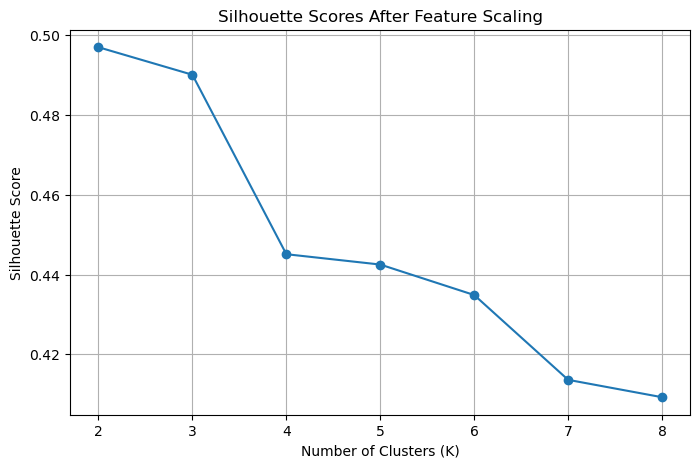

In [32]:
plt.figure(figsize=(8, 5))

plt.plot(
    scaled_k_values,
    scaled_silhouette_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Scores After Feature Scaling")

plt.xticks(scaled_k_values)
plt.grid(True)

plt.show()

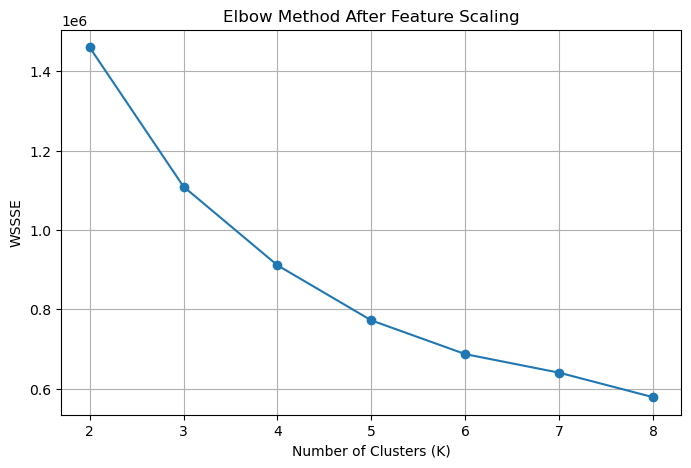

In [33]:
plt.figure(figsize=(8, 5))

plt.plot(
    scaled_k_values,
    scaled_wssse_scores,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("WSSSE")
plt.title("Elbow Method After Feature Scaling")

plt.xticks(scaled_k_values)
plt.grid(True)

plt.show()

In [34]:
#Select K for the scaled model
scaled_evaluation = list(
    zip(
        scaled_k_values,
        scaled_silhouette_scores,
        scaled_wssse_scores
    )
)

for k, silhouette, wssse in scaled_evaluation:
    print(
        f"K = {k} | "
        f"Silhouette = {silhouette:.4f} | "
        f"WSSSE = {wssse:.2f}"
    )

best_scaled_result = max(
    scaled_evaluation,
    key=lambda x: x[1]
)

best_scaled_k = best_scaled_result[0]

print("\nSelected K:", best_scaled_k)
print("Silhouette:", round(best_scaled_result[1], 4))
print("WSSSE:", round(best_scaled_result[2], 2))

K = 2 | Silhouette = 0.4969 | WSSSE = 1460676.68
K = 3 | Silhouette = 0.4900 | WSSSE = 1109363.13
K = 4 | Silhouette = 0.4451 | WSSSE = 911098.01
K = 5 | Silhouette = 0.4425 | WSSSE = 772207.63
K = 6 | Silhouette = 0.4349 | WSSSE = 687180.07
K = 7 | Silhouette = 0.4136 | WSSSE = 640389.52
K = 8 | Silhouette = 0.4093 | WSSSE = 578616.54

Selected K: 2
Silhouette: 0.4969
WSSSE: 1460676.68


In [35]:
#Train the final scaled K-Means model
final_scaled_kmeans = KMeans(
    k=best_scaled_k,
    seed=42,
    featuresCol="scaled_features",
    predictionCol="prediction"
)

final_scaled_model = final_scaled_kmeans.fit(
    scaled_cluster_sample
)

print("Final scaled K-Means model trained successfully.")

Final scaled K-Means model trained successfully.


In [36]:
#Examine the scaled cluster centres
scaled_centers = final_scaled_model.clusterCenters()

for i, center in enumerate(scaled_centers):
    print(
        f"Cluster {i}:",
        [round(float(value), 4) for value in center]
    )

Cluster 0: [0.7557, -0.6287, -0.0152]
Cluster 1: [-0.8658, 0.718, 0.0143]


In [37]:
import numpy as np

feature_means = np.array(
    scaler_model.mean.toArray()
)

feature_stds = np.array(
    scaler_model.std.toArray()
)

original_centers = []

for i, center in enumerate(scaled_centers):

    original_center = (
        np.array(center) * feature_stds
        + feature_means
    )

    original_centers.append(original_center)

    print(
        f"Cluster {i}: "
        f"Latitude={original_center[0]:.6f}, "
        f"Longitude={original_center[1]:.6f}, "
        f"Hour={original_center[2]:.2f}"
    )

Cluster 0: Latitude=41.907567, Longitude=-87.708539, Hour=13.05
Cluster 1: Latitude=41.767448, Longitude=-87.629049, Hour=13.25


In [38]:
#Apply the scaled model to the full dataset
full_scaled_predictions = final_scaled_model.transform(
    scaled_cluster_features
)

print(
    "Full clustered records:",
    full_scaled_predictions.count()
)

Full clustered records: 7697698


In [39]:
scaled_cluster_summary = (
    full_scaled_predictions
    .groupBy("prediction")
    .agg(
        F.count("*").alias("crime_count"),
        F.avg("latitude_clean").alias("avg_latitude"),
        F.avg("longitude_clean").alias("avg_longitude"),
        F.avg("crime_hour").alias("avg_crime_hour"),
        F.countDistinct("district_clean").alias("district_count"),
        F.countDistinct("community_area_clean").alias("community_count")
    )
    .orderBy("prediction")
)

scaled_cluster_summary.show(truncate=False)

+----------+-----------+-----------------+------------------+------------------+--------------+---------------+
|prediction|crime_count|avg_latitude     |avg_longitude     |avg_crime_hour    |district_count|community_count|
+----------+-----------+-----------------+------------------+------------------+--------------+---------------+
|0         |4111630    |41.90747984817517|-87.70849977747882|13.066677692302079|22            |57             |
|1         |3586068    |41.76748969146092|-87.62893060165446|13.250776337760467|22            |50             |
+----------+-----------+-----------------+------------------+------------------+--------------+---------------+



In [40]:
total_records = full_scaled_predictions.count()

scaled_cluster_summary_percentage = (
    scaled_cluster_summary
    .withColumn(
        "percentage",
        F.round(
            F.col("crime_count") / F.lit(total_records) * 100,
            2
        )
    )
)

scaled_cluster_summary_percentage.show(
    truncate=False
)

+----------+-----------+-----------------+------------------+------------------+--------------+---------------+----------+
|prediction|crime_count|avg_latitude     |avg_longitude     |avg_crime_hour    |district_count|community_count|percentage|
+----------+-----------+-----------------+------------------+------------------+--------------+---------------+----------+
|0         |4111630    |41.90747984817517|-87.70849977747882|13.066677692302079|22            |57             |53.41     |
|1         |3586068    |41.76748969146092|-87.62893060165446|13.250776337760467|22            |50             |46.59     |
+----------+-----------+-----------------+------------------+------------------+--------------+---------------+----------+



In [41]:
#Cluster distribution across police districts
cluster_district_distribution = (
    full_scaled_predictions
    .groupBy(
        "prediction",
        "district_clean"
    )
    .count()
    .orderBy(
        "prediction",
        F.desc("count")
    )
)

cluster_district_distribution.show(100, truncate=False)

+----------+--------------+------+
|prediction|district_clean|count |
+----------+--------------+------+
|0         |11            |492761|
|0         |25            |438188|
|0         |12            |367394|
|0         |19            |345044|
|0         |10            |332173|
|0         |15            |330605|
|0         |18            |315998|
|0         |14            |297654|
|0         |16            |256815|
|0         |24            |232403|
|0         |17            |222373|
|0         |8             |216644|
|0         |20            |136067|
|0         |9             |70552 |
|0         |1             |56732 |
|0         |31            |189   |
|0         |NULL          |25    |
|0         |6             |4     |
|0         |22            |3     |
|0         |2             |3     |
|0         |4             |1     |
|0         |7             |1     |
|0         |5             |1     |
|1         |6             |451215|
|1         |7             |446403|
|1         |4       

In [42]:
#Calculate district percentages within clusters
cluster_totals = (
    full_scaled_predictions
    .groupBy("prediction")
    .count()
    .withColumnRenamed("count", "cluster_total")
)

cluster_district_analysis = (
    cluster_district_distribution
    .join(
        cluster_totals,
        on="prediction",
        how="left"
    )
    .withColumn(
        "district_percentage",
        F.round(
            F.col("count") /
            F.col("cluster_total") * 100,
            2
        )
    )
    .orderBy(
        "prediction",
        F.desc("district_percentage")
    )
)

cluster_district_analysis.show(
    100,
    truncate=False
)

+----------+--------------+------+-------------+-------------------+
|prediction|district_clean|count |cluster_total|district_percentage|
+----------+--------------+------+-------------+-------------------+
|0         |11            |492761|4111630      |11.98              |
|0         |25            |438188|4111630      |10.66              |
|0         |12            |367394|4111630      |8.94               |
|0         |19            |345044|4111630      |8.39               |
|0         |10            |332173|4111630      |8.08               |
|0         |15            |330605|4111630      |8.04               |
|0         |18            |315998|4111630      |7.69               |
|0         |14            |297654|4111630      |7.24               |
|0         |16            |256815|4111630      |6.25               |
|0         |24            |232403|4111630      |5.65               |
|0         |17            |222373|4111630      |5.41               |
|0         |8             |216644|

In [43]:
#Identify how many districts each cluster spans
cluster_district_coverage = (
    full_scaled_predictions
    .groupBy("prediction")
    .agg(
        F.countDistinct("district_clean").alias(
            "district_count"
        )
    )
    .orderBy("prediction")
)

cluster_district_coverage.show()

+----------+--------------+
|prediction|district_count|
+----------+--------------+
|         0|            22|
|         1|            22|
+----------+--------------+



In [44]:
from pyspark.sql.window import Window

district_rank_window = Window.partitionBy(
    "prediction"
).orderBy(
    F.desc("district_percentage")
)

dominant_districts = (
    cluster_district_analysis
    .withColumn(
        "district_rank",
        F.row_number().over(district_rank_window)
    )
    .filter(F.col("district_rank") <= 5)
    .orderBy(
        "prediction",
        "district_rank"
    )
)

dominant_districts.show(
    100,
    truncate=False
)

+----------+--------------+------+-------------+-------------------+-------------+
|prediction|district_clean|count |cluster_total|district_percentage|district_rank|
+----------+--------------+------+-------------+-------------------+-------------+
|0         |11            |492761|4111630      |11.98              |1            |
|0         |25            |438188|4111630      |10.66              |2            |
|0         |12            |367394|4111630      |8.94               |3            |
|0         |19            |345044|4111630      |8.39               |4            |
|0         |10            |332173|4111630      |8.08               |5            |
|1         |6             |451215|3586068      |12.58              |1            |
|1         |7             |446403|3586068      |12.45              |2            |
|1         |4             |438177|3586068      |12.22              |3            |
|1         |3             |391069|3586068      |10.91              |4            |
|1  

In [47]:
#Analyze community areas
cluster_community_distribution = (
    full_scaled_predictions
    .groupBy(
        "prediction",
        "community_area_clean"
    )
    .count()
    .orderBy(
        "prediction",
        F.desc("count")
    )
)

cluster_community_distribution.show(
    100,
    truncate=False
)

+----------+--------------------+------+
|prediction|community_area_clean|count |
+----------+--------------------+------+
|0         |25                  |443879|
|0         |NULL                |328880|
|0         |8                   |222916|
|0         |23                  |221462|
|0         |24                  |207617|
|0         |29                  |206612|
|0         |28                  |199015|
|0         |22                  |146509|
|0         |6                   |142812|
|0         |26                  |133804|
|0         |27                  |132752|
|0         |19                  |129898|
|0         |30                  |119210|
|0         |7                   |110029|
|0         |1                   |109332|
|0         |3                   |103796|
|0         |2                   |90727 |
|0         |15                  |89835 |
|0         |16                  |80059 |
|0         |77                  |70964 |
|0         |21                  |65613 |
|0         |14  

In [48]:
#Calculate community percentages
cluster_community_totals = (
    full_scaled_predictions
    .groupBy("prediction")
    .count()
    .withColumnRenamed(
        "count",
        "cluster_total"
    )
)

cluster_community_analysis = (
    cluster_community_distribution
    .join(
        cluster_community_totals,
        on="prediction",
        how="left"
    )
    .withColumn(
        "community_percentage",
        F.round(
            F.col("count") /
            F.col("cluster_total") * 100,
            2
        )
    )
    .orderBy(
        "prediction",
        F.desc("community_percentage")
    )
)

cluster_community_analysis.show(
    100,
    truncate=False
)

+----------+--------------------+------+-------------+--------------------+
|prediction|community_area_clean|count |cluster_total|community_percentage|
+----------+--------------------+------+-------------+--------------------+
|0         |25                  |443879|4111630      |10.8                |
|0         |NULL                |328880|4111630      |8.0                 |
|0         |8                   |222916|4111630      |5.42                |
|0         |23                  |221462|4111630      |5.39                |
|0         |24                  |207617|4111630      |5.05                |
|0         |29                  |206612|4111630      |5.03                |
|0         |28                  |199015|4111630      |4.84                |
|0         |22                  |146509|4111630      |3.56                |
|0         |6                   |142812|4111630      |3.47                |
|0         |26                  |133804|4111630      |3.25                |
|0         |

In [49]:
#Find the top 5 community areas per cluster
community_rank_window = Window.partitionBy(
    "prediction"
).orderBy(
    F.desc("community_percentage")
)

top_communities = (
    cluster_community_analysis
    .withColumn(
        "community_rank",
        F.row_number().over(
            community_rank_window
        )
    )
    .filter(
        F.col("community_rank") <= 5
    )
    .orderBy(
        "prediction",
        "community_rank"
    )
)

top_communities.show(
    100,
    truncate=False
)

+----------+--------------------+------+-------------+--------------------+--------------+
|prediction|community_area_clean|count |cluster_total|community_percentage|community_rank|
+----------+--------------------+------+-------------+--------------------+--------------+
|0         |25                  |443879|4111630      |10.8                |1             |
|0         |NULL                |328880|4111630      |8.0                 |2             |
|0         |8                   |222916|4111630      |5.42                |3             |
|0         |23                  |221462|4111630      |5.39                |4             |
|0         |24                  |207617|4111630      |5.05                |5             |
|1         |NULL                |275456|3586068      |7.68                |1             |
|1         |43                  |234561|3586068      |6.54                |2             |
|1         |67                  |203235|3586068      |5.67                |3             |

In [50]:
plot_sample = (
    full_scaled_predictions
    .select(
        "latitude_clean",
        "longitude_clean",
        "crime_hour",
        "prediction"
    )
    .sample(
        withReplacement=False,
        fraction=0.01,
        seed=42
    )
    .toPandas()
)

print("Plot sample rows:", len(plot_sample))
plot_sample.head()

Plot sample rows: 77005


,latitude_clean,longitude_clean,crime_hour,prediction
0,41.795787,-87.761910,15,0
1,41.816791,-87.723902,19,0
2,41.797984,-87.723299,13,0
3,41.793490,-87.705156,16,1
4,41.756483,-87.715262,21,1


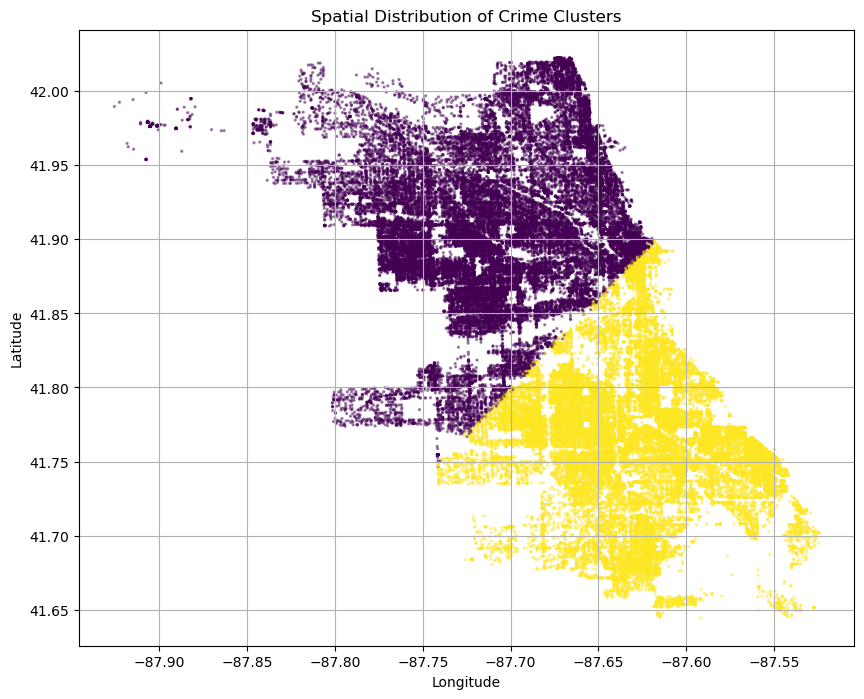

In [51]:
plt.figure(figsize=(10, 8))

plt.scatter(
    plot_sample["longitude_clean"],
    plot_sample["latitude_clean"],
    c=plot_sample["prediction"],
    s=2,
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Crime Clusters")

plt.grid(True)
plt.show()

In [56]:
cluster_hourly = (
    full_scaled_predictions
    .groupBy(
        "prediction",
        "crime_hour"
    )
    .count()
    .orderBy(
        "prediction",
        "crime_hour"
    )
)

cluster_hourly_pd = cluster_hourly.toPandas()

print(cluster_hourly_pd.head(20))

    prediction  crime_hour   count
0            0           0  240381
1            0           1  136761
2            0           2  118003
3            0           3   95146
4            0           4   71071
5            0           5   57755
6            0           6   67171
7            0           7   94227
8            0           8  136601
9            0           9  172379
10           0          10  170039
11           0          11  177040
12           0          12  230841
13           0          13  190011
14           0          14  202745
15           0          15  213955
16           0          16  202630
17           0          17  209539
18           0          18  225901
19           0          19  233649


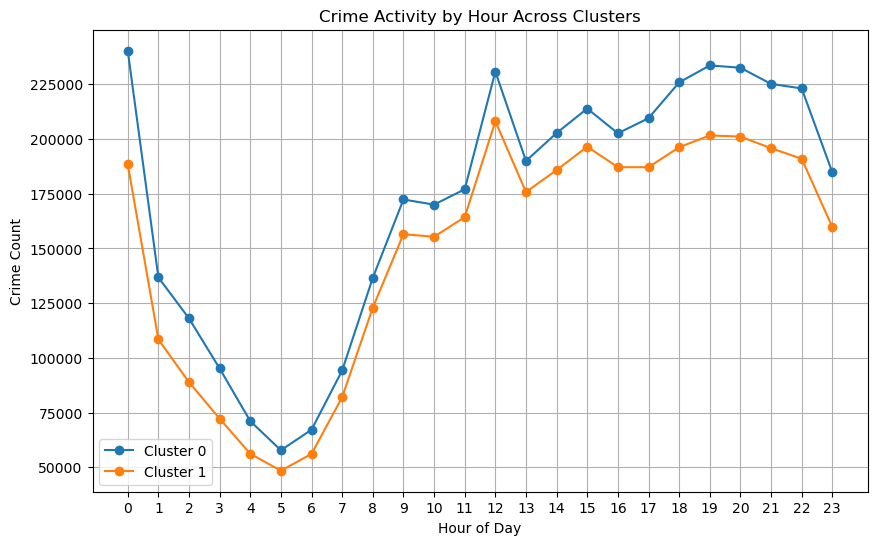

In [57]:
plt.figure(figsize=(10, 6))

for cluster_id in sorted(
    cluster_hourly_pd["prediction"].unique()
):
    cluster_data = cluster_hourly_pd[
        cluster_hourly_pd["prediction"] == cluster_id
    ]

    plt.plot(
        cluster_data["crime_hour"],
        cluster_data["count"],
        marker="o",
        label=f"Cluster {cluster_id}"
    )

plt.xlabel("Hour of Day")
plt.ylabel("Crime Count")
plt.title("Crime Activity by Hour Across Clusters")

plt.xticks(range(0, 24))
plt.legend()
plt.grid(True)

plt.show()

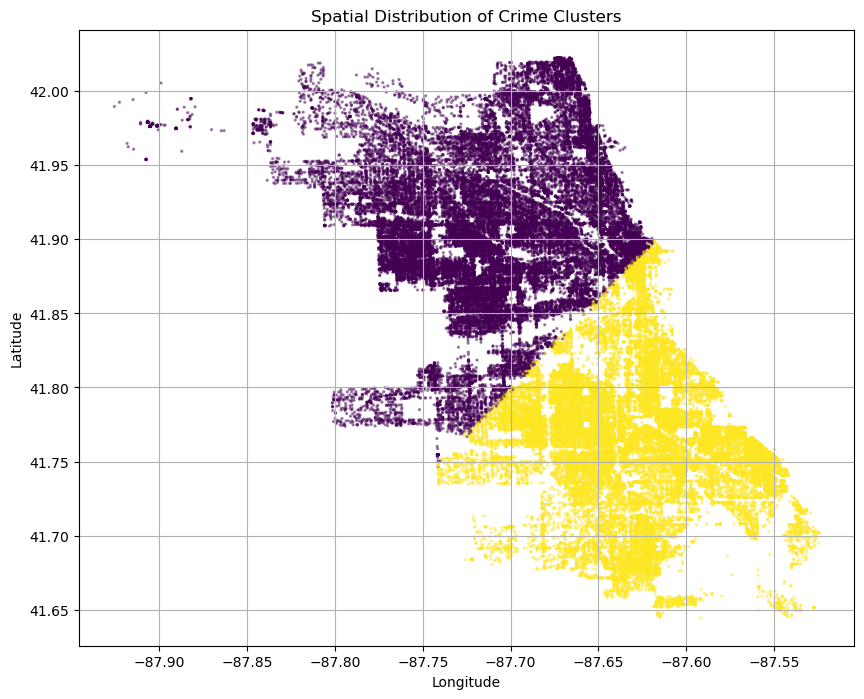

Saved: C:\Users\HP\Documents\Big Data Technology\figures\task3\spatial_clusters.png


In [58]:
TASK3_PATH = os.path.join(
    PROCESSED_PATH,
    "task3_clustering"
)

FIGURE3_PATH = os.path.join(
    BASE_PATH,
    "figures",
    "task3"
)

os.makedirs(TASK3_PATH, exist_ok=True)
os.makedirs(FIGURE3_PATH, exist_ok=True)

spatial_figure_path = os.path.join(
    FIGURE3_PATH,
    "spatial_clusters.png"
)

plt.figure(figsize=(10, 8))

plt.scatter(
    plot_sample["longitude_clean"],
    plot_sample["latitude_clean"],
    c=plot_sample["prediction"],
    s=2,
    alpha=0.4
)

plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.title("Spatial Distribution of Crime Clusters")

plt.grid(True)

plt.savefig(
    spatial_figure_path,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print("Saved:", spatial_figure_path)

In [60]:
CLUSTERED_PARQUET_PATH = os.path.join(
    TASK3_PATH,
    "clustered_crime_parquet"
)

(
    full_scaled_predictions
    .write
    .mode("overwrite")
    .format("parquet")
    .partitionBy("prediction")
    .save(CLUSTERED_PARQUET_PATH)
)

print("Clustered crime dataset saved successfully.")

Clustered crime dataset saved successfully.
